# Arbitrage Pricing Theory

Arbitrage Pricing Theory (APT) is a major asset pricing theory that relies on expressing the returns using a linear factor model:

$$
R_i = a_i + b_{i1}F_1 + b_{i2}F_2 + \dots + b_{ik}F_K + \epsilon_i
$$

This theory states that if we have modelled our rate of return as above, then the **expected returns** obey:

$$
E(R_i) = R_F + b_{i1}\lambda_1 + b_{i2}\lambda_2 + \dots + b_{ik}\lambda_K
$$

where  
- $R_F$ is the risk-free rate  
- $\lambda_j$ is the risk premium — the return in excess of the risk-free rate — for factor $j$

This premium arises because investors require higher returns to compensate them for incurring that factor risk. This generalizes the Capital Asset Pricing Model (CAPM).

We can estimate the $\lambda_j$ by constructing a **pure factor portfolio** for factor $j$ — that is, a portfolio that has sensitivity (beta) = 1 to factor $j$ and 0 to all other factors (and ideally well-diversified so asset-specific risk $\epsilon_p \approx 0$), and then solve the resulting system of linear equations.

#### Arbitrage in APT

In the Arbitrage Pricing Theory, there are many securities in the universe. If we use different ones to compute the $\lambda$s, our results are **inconsistent**, then there is an **arbitrage opportunity** (in expectation). **Arbitrage** is an operation that earns a profit without (systematic) risk and without net investment of money. An arbitrage opportunity occurs when there is a risk-free investment with expected positive return that requires net investment, or when expectations of returns are inconsistent.

For instance, there is no arbitrage opportunity in the following case:  
Say there is an asset with expected rate of return 0.20 for the next year, while $\beta = 1.2$ with the market, the market is expected to have a rate of return of 0.10, and the risk-free rate on 1-year bonds is 0.05. Then the APT model tells us that the expected return on the asset **should** be:

$$
R_P + \beta\lambda = 0.05 + 1.2(0.10 - 0.05) = 0.11
$$

This does **not** agree with the prediction that the expected return is 0.20. So we can take advantage of this:
- Short $120 of the asset  
- Buy $100 of bonds (risk-free)  

We have invested net zero money (short sale proceeds fund the bond purchase), we are short systematic risk (market-neutral), but we expect to earn:

$$
0.20 \times 100 - 0.10 \times 120 + 0.05 \times 120 = 20 - 12 + 6 = 14 \text{ dollars?}
$$

(or similar calculation — the text shows ≈9 dollars profit in one version). The arbitrage opportunity persists until prices adjust and the arbitrage opportunities disappear. That is, the APT assumes there are arbitrageurs who have sufficient amounts of **patience** and **capital**. This provides justification for the use of empirical factor models in pricing: if the model were inconsistent, there would be an arbitrage opportunity, so prices would adjust.

**Often both ways** — it is incredibly difficult to know the true expected returns, but notice that this model tells us what the **expected returns should be** if the market is fully arbitraged. This lays the groundwork for long-short equity strategies based on factor model ranking systems. You know what the expected return **should be** given the market will (mostly) arbitrage over the timeframe on which you are trading, then you can construct a ranking.

#### Long-Short Equity

To do this, estimate the expected return for each asset on the market, rank them. Long the top percentile and short the bottom percentile. Said another way: if the assets at the top of the ranking on average tend to make 6% more per year than the market, and assets at the bottom tend to make 5% less, then you will make:

$$
(M + 0.06) - (M - 0.05) = 0.11 \text{( i.e 11\% per year)}
$$

(or example numbers: top make +10%, bottom make –5% → spread ≈ 0.10 – (–0.05) = 0.15 or 15%). 

Long-short equity accepts that any **individual** asset is very difficult to model / predict accurately, but relies on broad trends holding and errors averaging out across many assets (e.g., a group of 1000 assets). We cannot accurately predict any single one, but we can get the **group average** expected returns.

#### How many factors should we have in our model?

Recall that overfitting occurs when we have more factors that explain the model accurately on the train dataset, but fail to generalise in the test or unseen data. In short, increasing the number of factros will explain more of your returns, but at the cost of being more fit to the noise in your data. You should ideally strive for having few parameters as much as possible that still explain a large amount of the variance in returns.

Import the necessary librares

In [45]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

from matplotlib import pyplot as plt
from statsmodels import regression
from statsmodels import api as sm
from statsmodels.regression.rolling import RollingOLS

# Silence warnings
warnings.filterwarnings("ignore")

#### Arbitrage Pricing using Real World Data (analysis of two assets)

#### Step 1: Computing the Returns for Two Assets

Over here, we define two different sets of start and end date:
- *start_date, end_date*: This will be used to query the data for our factors
- *offset_start_date, offset_end_date*: This will be used to query the data for our dependent variable (assets)

What we are trying to do here is to validate and show where the future returns (computed using *offset_start_date, offset_end_date*) can be explained using the present day data (*start_date, end_date*) for our factors. In essence, our **Hypothesis** is:

"Are the returns 30-days into the future predicted for by these factors today?"

In [46]:
start_date = '2014-06-01'
end_date = '2015-06-01'

# We will look into the retunrs of an asset one month into the future
offset_start_date = '2014-07-01'
offset_end_date = '2015-07-01'

asset1_ticker = 'AAPL'
asset2_ticker = 'MSFT'
benchmark_ticker = 'SPY'
etf_ticker = 'BIL' # An ETF that tracks short-term US Treasury bills, often used as a proxy for the risk-free rate

# Download the data for the two assets, the benchmark, and the technology ETF
asset1_data = yf.download(asset1_ticker, offset_start_date, offset_end_date) # Get the data for the first asset with the offset dates
asset2_data = yf.download(asset2_ticker, offset_start_date, offset_end_date) # Get the data for the second asset with the offset dates
benchmark_data = yf.download(benchmark_ticker, start_date, end_date) # Get the data for the benchmark with the original dates
etf_data = yf.download(etf_ticker, start_date, end_date) # Get the data for the technology ETF with the original dates

# Compute their returns
asset1_returns = asset1_data['Close'].pct_change().dropna()
asset2_returns = asset2_data['Close'].pct_change().dropna()
benchmark_returns = benchmark_data['Close'].pct_change().dropna()
etf_returns = etf_data['Close'].pct_change().dropna()     

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [47]:
# Create a pandas dataframe to store the returns and create a constant term for the regression
data = pd.DataFrame({
    'Asset1': asset1_returns[asset1_ticker],
    'Asset2': asset2_returns[asset2_ticker],
    'Benchmark': benchmark_returns[benchmark_ticker],
    'RiskFree': etf_returns[etf_ticker]
}, index=asset1_returns.index).dropna()

data['Constant'] = 1
data.head()

,Asset1,Asset2,Benchmark,RiskFree,Constant
Date,,,,,
2014-07-02,-0.000428,0.000716,0.001015,0.000000,1
2014-07-03,0.005884,-0.002387,0.004918,-0.000218,1
2014-07-07,0.020632,0.004545,-0.003481,0.000218,1
2014-07-08,-0.006461,-0.005001,-0.006430,0.000000,1
2014-07-09,0.000420,-0.002633,0.004484,-0.000218,1


#### Step 2: Compute the static regression over the whole time period

In [48]:
ols_model = regression.linear_model.OLS(data['Asset1'], data[['Constant', 'Benchmark', 'RiskFree']])
ols_results = ols_model.fit()
print("p-values for running OLS regression on Asset1:", ols_results.f_pvalue)
print("OLS Parameters for Asset1:\n", ols_results.params)
r1_params = ols_results.params
print("\n")
ols_model = regression.linear_model.OLS(data['Asset2'], data[['Constant', 'Benchmark', 'RiskFree']])
ols_results = ols_model.fit()
print("p-values for running OLS regression on Asset2:", ols_results.f_pvalue)
print("OLS Parameters for Asset2:\n", ols_results.params)
r2_params = ols_results.params

p-values for running OLS regression on Asset1: 3.2635871685728865e-22
OLS Parameters for Asset1:
 Constant     0.001167
Benchmark    1.100179
RiskFree    -4.168697
dtype: float64


p-values for running OLS regression on Asset2: 7.759484695902184e-21
OLS Parameters for Asset2:
 Constant     0.000293
Benchmark    1.176583
RiskFree     5.972335
dtype: float64


Again, these numbers do not tell us much by themselves, and we have to make sense of them by looking at the distribution pf estimated coefficients and whether they are stable. For that, we can analyse their 90-day regression.

Plot the rolling 90-day beta regression along with our regression coefficients computed above for Asset 1

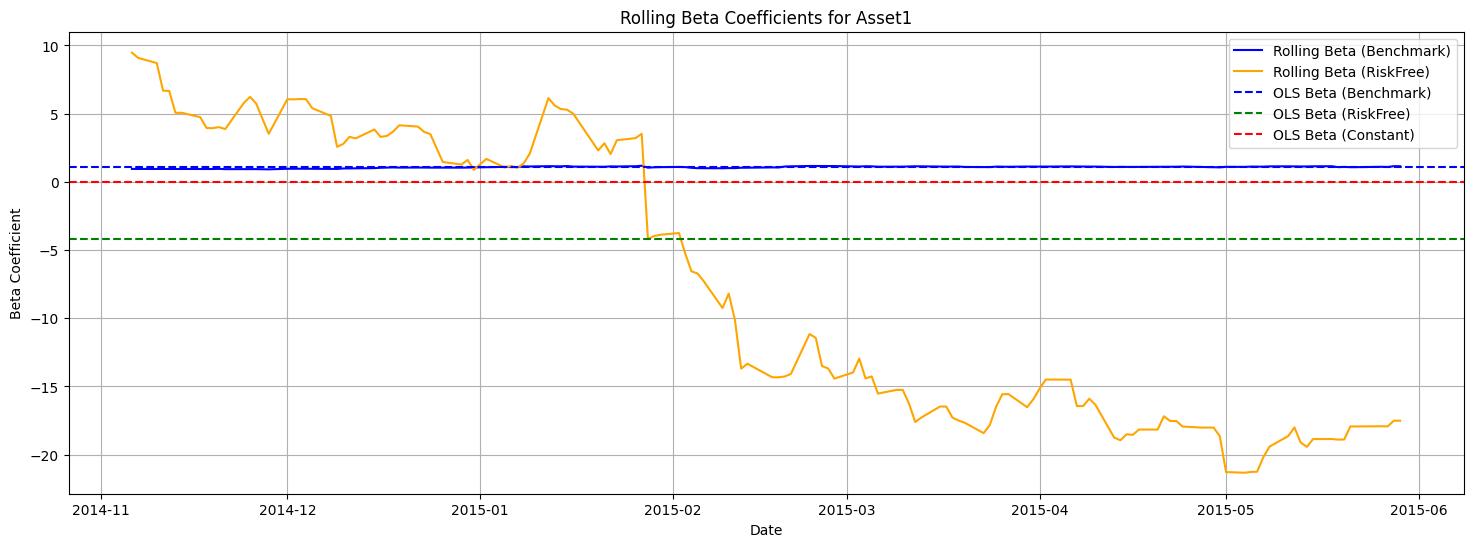

In [50]:
Y = data['Asset1']
X = data[['Benchmark', 'RiskFree']]

# Rolling regression with a window of 90 days
rolling_model = RollingOLS(Y, X, window=90)
rolling_results = rolling_model.fit()

# Extract the rolling beta coefficients
rolling_betas = rolling_results.params

# Plot the rolling beta coefficients
plt.figure(figsize=(18, 6))
plt.plot(rolling_betas.index, rolling_betas['Benchmark'], label='Rolling Beta (Benchmark)', color='blue')
plt.plot(rolling_betas.index, rolling_betas['RiskFree'], label='Rolling Beta (RiskFree)', color='orange')
plt.title('Rolling Beta Coefficients for Asset1')

# Plot the horizontal lines for the OLS beta coefficients
plt.axhline(y=r1_params['Benchmark'], color='blue', linestyle='--', label='OLS Beta (Benchmark)')
plt.axhline(y=r1_params['RiskFree'], color='green', linestyle='--', label='OLS Beta (RiskFree)')
plt.axhline(y=r1_params['Constant'], color='red', linestyle='--', label='OLS Beta (Constant)')

plt.xlabel('Date')
plt.ylabel('Beta Coefficient')
plt.legend()
plt.grid()
plt.show()

Plot the rolling 90-day beta regression along with our regression coefficients computed above for Asset 2

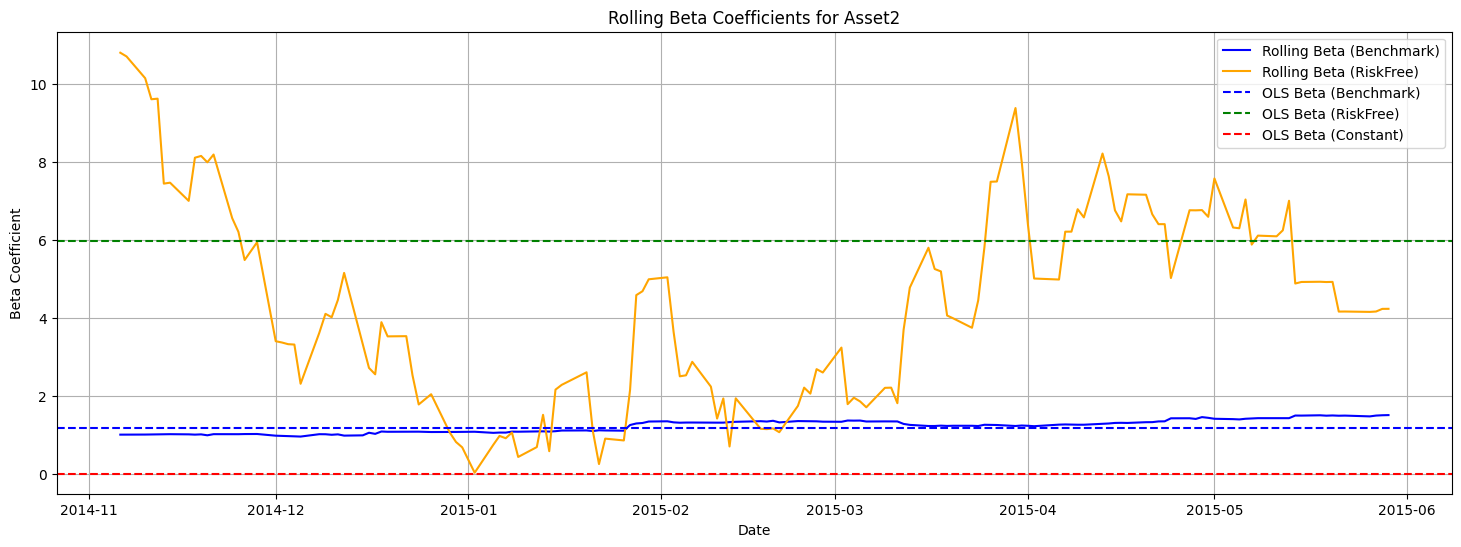

In [51]:
Y = data['Asset2']
X = data[['Benchmark', 'RiskFree']]

# Rolling regression with a window of 90 days
rolling_model = RollingOLS(Y, X, window=90)
rolling_results = rolling_model.fit()

# Extract the rolling beta coefficients
rolling_betas = rolling_results.params

# Plot the rolling beta coefficients
plt.figure(figsize=(18, 6))
plt.plot(rolling_betas.index, rolling_betas['Benchmark'], label='Rolling Beta (Benchmark)', color='blue')
plt.plot(rolling_betas.index, rolling_betas['RiskFree'], label='Rolling Beta (RiskFree)', color='orange')
plt.title('Rolling Beta Coefficients for Asset2')

# Plot the horizontal lines for the OLS beta coefficients
plt.axhline(y=r2_params['Benchmark'], color='blue', linestyle='--', label='OLS Beta (Benchmark)')
plt.axhline(y=r2_params['RiskFree'], color='green', linestyle='--', label='OLS Beta (RiskFree)')
plt.axhline(y=r2_params['Constant'], color='red', linestyle='--', label='OLS Beta (Constant)')

plt.xlabel('Date')
plt.ylabel('Beta Coefficient')
plt.legend()
plt.grid()
plt.show()

#### Step 3: Predicting the future

Assuming the models we used above are valid, let us deploy them to predict future prices for these assets.

In [57]:
start_date = '2014-07-25'
end_date = '2015-07-25'

offset_start_date = '2014-08-25'
offset_end_date = '2015-08-25'

asset1_ticker = 'AAPL'
benchmark_ticker = 'SPY'
etf_ticker = 'BIL'
asset1_return = yf.download(asset1_ticker, offset_start_date, offset_end_date)['Close'].pct_change().dropna()
benchmark_return = yf.download(benchmark_ticker, offset_start_date, offset_end_date)['Close'].pct_change().dropna()
etf_return = yf.download(etf_ticker, offset_start_date, offset_end_date)['Close'].pct_change().dropna()

# Define a constant to compute the intercept
constant = np.ones(len(asset1_return))

# Create the X matrix for regression
data = pd.DataFrame({
    'Constant': constant,
    'Benchmark': benchmark_return[benchmark_ticker],
    'RiskFree': etf_return[etf_ticker],
    'Asset1': asset1_return[asset1_ticker]
}, index=asset1_return.index).dropna()

# Perform a historical regression to get the beta coefficients
ols_model = regression.linear_model.OLS(data['Asset1'], data[['Constant', 'Benchmark', 'RiskFree']])
ols_results = ols_model.fit()
print("p-values for running OLS regression on Asset1:\n", ols_results.f_pvalue)
print("OLS Parameters for Asset1:\n", ols_results.params)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

p-values for running OLS regression on Asset1:
 2.940160502995519e-27
OLS Parameters for Asset1:
 Constant     0.000357
Benchmark    1.146202
RiskFree    -2.524704
dtype: float64


Get the factor data for the last month so that we can predict the next month

In [58]:
start_date = '2014-07-25'
end_date = '2015-08-25'

# Get the returns for the market
last_month_benchmark_return = yf.download(benchmark_ticker, start_date, end_date)['Close'].pct_change().dropna()
last_month_etf_return = yf.download(etf_ticker, start_date, end_date)['Close'].pct_change().dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Compute the predictions

[*********************100%***********************]  1 of 1 completed


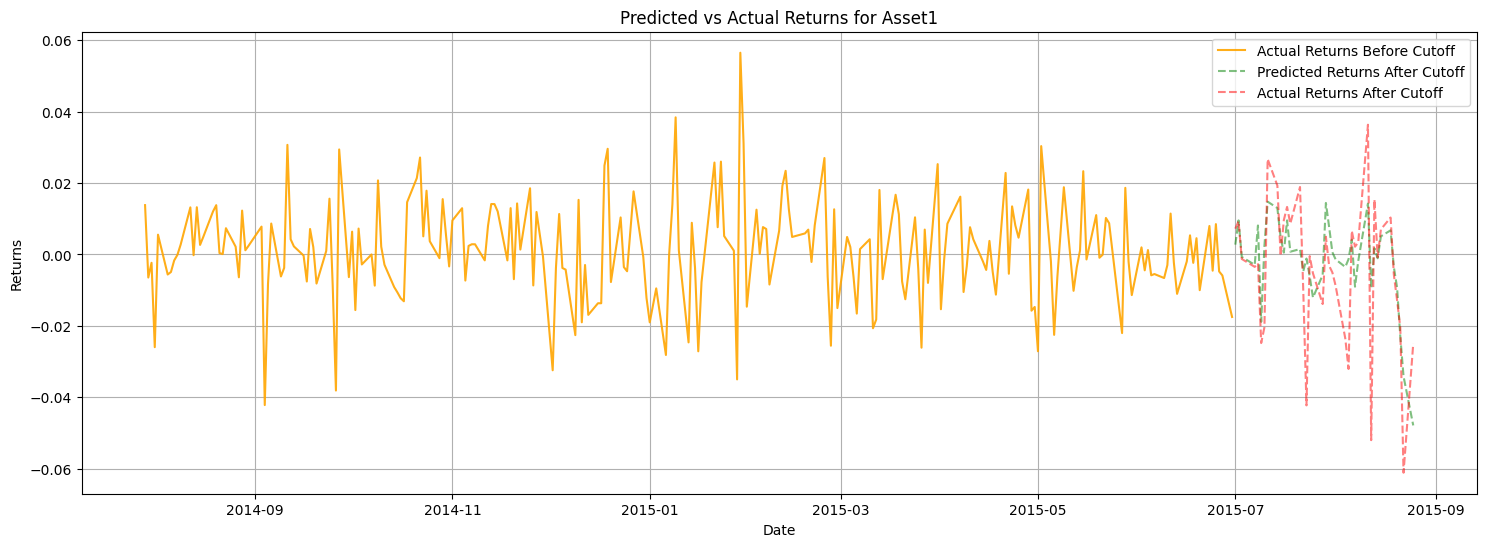

In [99]:
b_SPY = ols_results.params['Benchmark']
b_BIL = ols_results.params['RiskFree']
b_Constant = ols_results.params['Constant']

predictions = b_Constant + b_SPY * last_month_benchmark_return[benchmark_ticker] + b_BIL * last_month_etf_return[etf_ticker]
predictions.index = predictions.index + pd.DateOffset(days=1) # Shift the predictions by one day to align with the actual returns of the next day

# Plot the predictions against the actual of the next day
actual_returns = yf.download(asset1_ticker, start_date, end_date)['Close'].pct_change().dropna()
actual_returns.index = actual_returns.index + pd.DateOffset(days=1)

cutoff_date = '2015-07-01'
# Split actual returns
actual_before = actual_returns[actual_returns.index < cutoff_date]
actual_after = actual_returns[actual_returns.index >= cutoff_date]
# Split predictions
pred_after = predictions[predictions.index >= cutoff_date]

plt.figure(figsize=(18, 6))
plt.plot(actual_before.index, actual_before, label='Actual Returns Before Cutoff', color='orange', alpha=0.9)
plt.plot(pred_after.index, pred_after, linestyle='--', label='Predicted Returns After Cutoff', color='green', alpha=0.5)
plt.plot(actual_after.index, actual_after, linestyle='--', label='Actual Returns After Cutoff', color='red', alpha=0.5)
plt.title('Predicted vs Actual Returns for Asset1')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid()
plt.show()